## PIZZA SALES ANALYSIS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px

### Import Raw Data

In [2]:
df = pd.read_csv("E:/Data Analyst/Capstone Projects/pizza_sales.csv")

### Metadata of Raw Data

In [3]:
df.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,01-01-2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,01-01-2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,01-01-2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,01-01-2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,01-01-2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [4]:
df.tail(10)

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
48610,48611,21346,soppressata_l,1,31-12-2015,20:51:07,20.75,20.75,L,Supreme,"Soppressata Salami, Fontina Cheese, Mozzarella...",The Soppressata Pizza
48611,48612,21347,bbq_ckn_m,1,31-12-2015,21:14:37,16.75,16.75,M,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",The Barbecue Chicken Pizza
48612,48613,21347,ital_supr_m,1,31-12-2015,21:14:37,16.50,16.50,M,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
48613,48614,21347,peppr_salami_s,1,31-12-2015,21:14:37,12.50,12.50,S,Supreme,"Genoa Salami, Capocollo, Pepperoni, Tomatoes, ...",The Pepper Salami Pizza
48614,48615,21347,southw_ckn_l,1,31-12-2015,21:14:37,20.75,20.75,L,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja...",The Southwest Chicken Pizza
48615,48616,21348,ckn_alfredo_m,1,31-12-2015,21:23:10,16.75,16.75,M,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A...",The Chicken Alfredo Pizza
48616,48617,21348,four_cheese_l,1,31-12-2015,21:23:10,17.95,17.95,L,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",The Four Cheese Pizza
48617,48618,21348,napolitana_s,1,31-12-2015,21:23:10,12.00,12.00,S,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,...",The Napolitana Pizza
48618,48619,21349,mexicana_l,1,31-12-2015,22:09:54,20.25,20.25,L,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza
48619,48620,21350,bbq_ckn_s,1,31-12-2015,23:02:05,12.75,12.75,S,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",The Barbecue Chicken Pizza


In [5]:
print("The Metadata of the Dataset:", df.shape)

The Metadata of the Dataset: (48620, 12)


In [6]:
print("The Rows of the Dataset:", df.shape[0])

The Rows of the Dataset: 48620


In [7]:
print("The Columns of the Dataset:", df.shape[1])

The Columns of the Dataset: 12


In [8]:
df.columns

Index(['pizza_id', 'order_id', 'pizza_name_id', 'quantity', 'order_date',
       'order_time', 'unit_price', 'total_price', 'pizza_size',
       'pizza_category', 'pizza_ingredients', 'pizza_name'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  int64  
 1   order_id           48620 non-null  int64  
 2   pizza_name_id      48620 non-null  str    
 3   quantity           48620 non-null  int64  
 4   order_date         48620 non-null  str    
 5   order_time         48620 non-null  str    
 6   unit_price         48620 non-null  float64
 7   total_price        48620 non-null  float64
 8   pizza_size         48620 non-null  str    
 9   pizza_category     48620 non-null  str    
 10  pizza_ingredients  48620 non-null  str    
 11  pizza_name         48620 non-null  str    
dtypes: float64(2), int64(3), str(7)
memory usage: 4.5 MB


In [10]:
df.info

<bound method DataFrame.info of        pizza_id  order_id  pizza_name_id  quantity  order_date order_time  \
0             1         1     hawaiian_m         1  01-01-2015   11:38:36   
1             2         2  classic_dlx_m         1  01-01-2015   11:57:40   
2             3         2  five_cheese_l         1  01-01-2015   11:57:40   
3             4         2    ital_supr_l         1  01-01-2015   11:57:40   
4             5         2     mexicana_m         1  01-01-2015   11:57:40   
...         ...       ...            ...       ...         ...        ...   
48615     48616     21348  ckn_alfredo_m         1  31-12-2015   21:23:10   
48616     48617     21348  four_cheese_l         1  31-12-2015   21:23:10   
48617     48618     21348   napolitana_s         1  31-12-2015   21:23:10   
48618     48619     21349     mexicana_l         1  31-12-2015   22:09:54   
48619     48620     21350      bbq_ckn_s         1  31-12-2015   23:02:05   

       unit_price  total_price pizza_size p

### Data Types in Raw Data

In [11]:
df.dtypes

pizza_id               int64
order_id               int64
pizza_name_id            str
quantity               int64
order_date               str
order_time               str
unit_price           float64
total_price          float64
pizza_size               str
pizza_category           str
pizza_ingredients        str
pizza_name               str
dtype: object

In [12]:
df.describe()

,pizza_id,order_id,quantity,unit_price,total_price
count,48620.000000,48620.000000,48620.000000,48620.000000,48620.000000
mean,24310.500000,10701.479761,1.019622,16.494132,16.821474
std,14035.529381,6180.119770,0.143077,3.621789,4.437398
min,1.000000,1.000000,1.000000,9.750000,9.750000
25%,12155.750000,5337.000000,1.000000,12.750000,12.750000
50%,24310.500000,10682.500000,1.000000,16.500000,16.500000
75%,36465.250000,16100.000000,1.000000,20.250000,20.500000
max,48620.000000,21350.000000,4.000000,35.950000,83.000000


In [13]:
df.describe

<bound method NDFrame.describe of        pizza_id  order_id  pizza_name_id  quantity  order_date order_time  \
0             1         1     hawaiian_m         1  01-01-2015   11:38:36   
1             2         2  classic_dlx_m         1  01-01-2015   11:57:40   
2             3         2  five_cheese_l         1  01-01-2015   11:57:40   
3             4         2    ital_supr_l         1  01-01-2015   11:57:40   
4             5         2     mexicana_m         1  01-01-2015   11:57:40   
...         ...       ...            ...       ...         ...        ...   
48615     48616     21348  ckn_alfredo_m         1  31-12-2015   21:23:10   
48616     48617     21348  four_cheese_l         1  31-12-2015   21:23:10   
48617     48618     21348   napolitana_s         1  31-12-2015   21:23:10   
48618     48619     21349     mexicana_l         1  31-12-2015   22:09:54   
48619     48620     21350      bbq_ckn_s         1  31-12-2015   23:02:05   

       unit_price  total_price pizza_size

### KPI's

In [14]:
total_revenue = df['total_price'].sum()
total_pizzas_sold = df['quantity'].sum()
total_orders = df['order_id'].nunique()
avg_order_value = total_revenue / total_orders
avg_pizzas_per_order = total_pizzas_sold / total_orders

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Pizzas Sold: {total_pizzas_sold:,}")
print(f"Total Orders: {total_orders:,}")
print(f"Avg Order Value: ${avg_order_value:,.2f}")
print(f"Avg Pizzas Per Orders: {avg_pizzas_per_order:,.2f}")

Total Revenue: $817,860.05
Total Pizzas Sold: 49,574
Total Orders: 21,350
Avg Order Value: $38.31
Avg Pizzas Per Orders: 2.32


## Chart's

### Ingredient Analysis

In [15]:
ingredient = (
               df['pizza_ingredients']
               .str.split(',')
               .explode()
               .str.strip()
               .value_counts()
               .reset_index()
               .rename(columns={'index':'Count','pizza_ingredients':'Ingredients'})
             )
print(ingredient.head(10))

         Ingredients  count
0             Garlic  27422
1           Tomatoes  26601
2         Red Onions  19547
3        Red Peppers  16284
4  Mozzarella Cheese  10333
5          Pepperoni  10300
6            Spinach  10012
7          Mushrooms   9624
8            Chicken   8443
9          Capocollo   6572


### Daily Trend for Total Orders

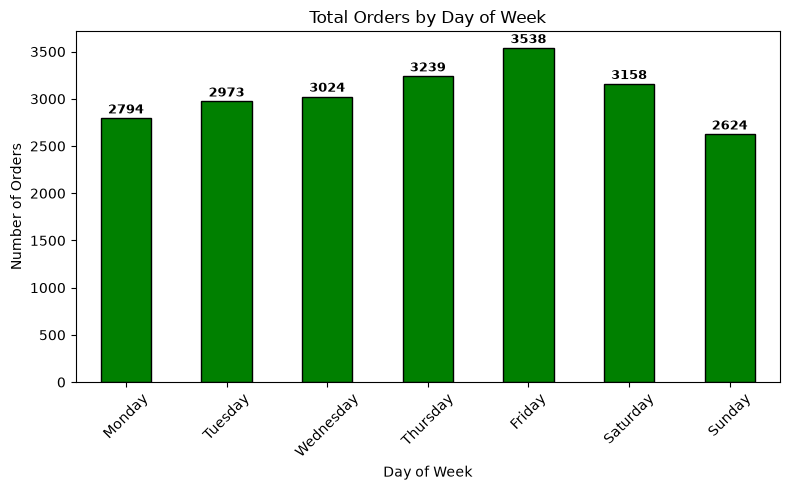

In [16]:
# 1. Convert order_date to datetime format
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

# 2. Extract day name
df['day_name'] = df['order_date'].dt.day_name()

# 3. Define weekday order (Monday to Sunday)
weekday_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday',
]

# 4. Categorize day names to preserve correct order in plots
df['day_name'] = pd.Categorical(
    df['day_name'], categories=weekday_order, ordered=True
)

# 5. Group by day of the week and count unique orders
orders_by_day = df.groupby('day_name', observed=False)['order_id'].nunique()

# 6. Plot the bar chart
ax = orders_by_day.plot(
    kind='bar', figsize=(8, 5), color='green', edgecolor='black'
)

plt.title('Total Orders by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)

# 7. Add data labels on top of each bar
for i, val in enumerate(orders_by_day):
  plt.text(
      i, val + 20, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold'
  )

plt.tight_layout()
plt.show()

### Daily Trend for Total Revenue

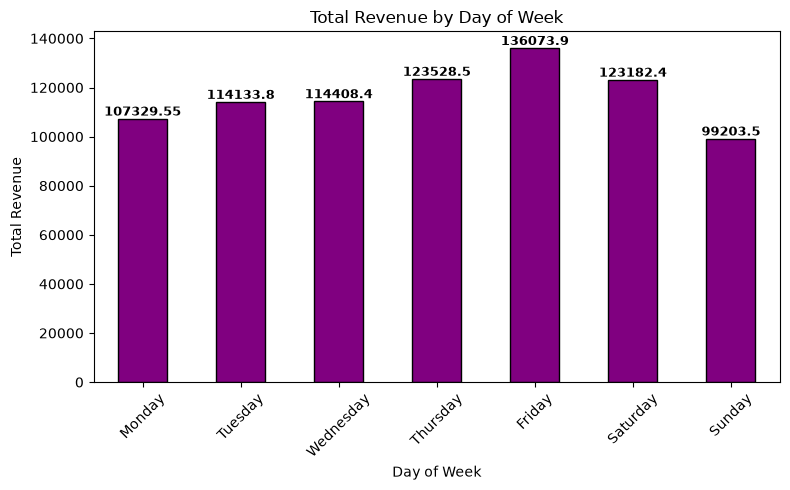

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Convert order_date to datetime format
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

# 2. Extract day name
df['day_name'] = df['order_date'].dt.day_name()

# 3. Define weekday order (Monday to Sunday)
weekday_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday',
]

# 4. Categorize day names to preserve correct order in plots
df['day_name'] = pd.Categorical(
    df['day_name'], categories=weekday_order, ordered=True
)

# 5. Group by day of week and calculate sum of total_price
orders_by_day = df.groupby('day_name', observed=False)['total_price'].sum()

# 6. Plot the bar chart
ax = orders_by_day.plot(
    kind='bar', figsize=(8, 5), color='purple', edgecolor='black'
)

plt.title('Total Revenue by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)

# 7. Add data labels on top of each bar
for i, val in enumerate(orders_by_day):
  plt.text(
      i,
      val + 20,
      str(val),
      ha='center',
      va='bottom',
      fontsize=9,
      fontweight='bold',
  )

plt.tight_layout()
plt.show()

# Hourly Trend for Total Orders

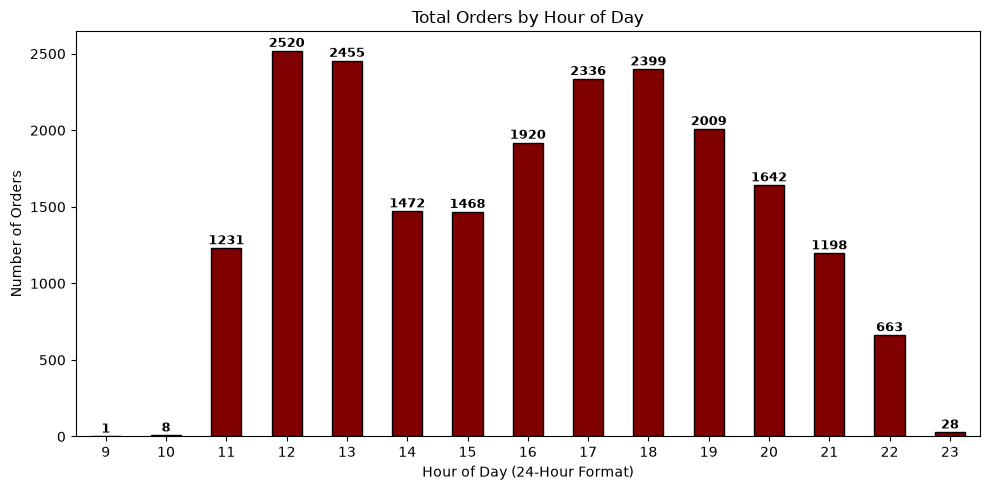

In [19]:
# 1. Convert order_time to datetime format
df['order_time'] = pd.to_datetime(df['order_time'], format='%H:%M:%S')

# 2. Extract the hour
df['order_hour'] = df['order_time'].dt.hour

# 3. Group by hour and count unique orders
orders_by_hour = df.groupby('order_hour', observed=False)[
    'order_id'
].nunique()

# 4. Plot the bar chart
ax = orders_by_hour.plot(
    kind='bar', figsize=(10, 5), color='maroon', edgecolor='black'
)

plt.title('Total Orders by Hour of Day')
plt.xlabel('Hour of Day (24-Hour Format)')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)

# 5. Add data labels on top of each bar
for i, val in enumerate(orders_by_hour):
  plt.text(
      i, val + 5, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold'
  )

plt.tight_layout()
plt.show()

### Hourly Trend for Total Revenue

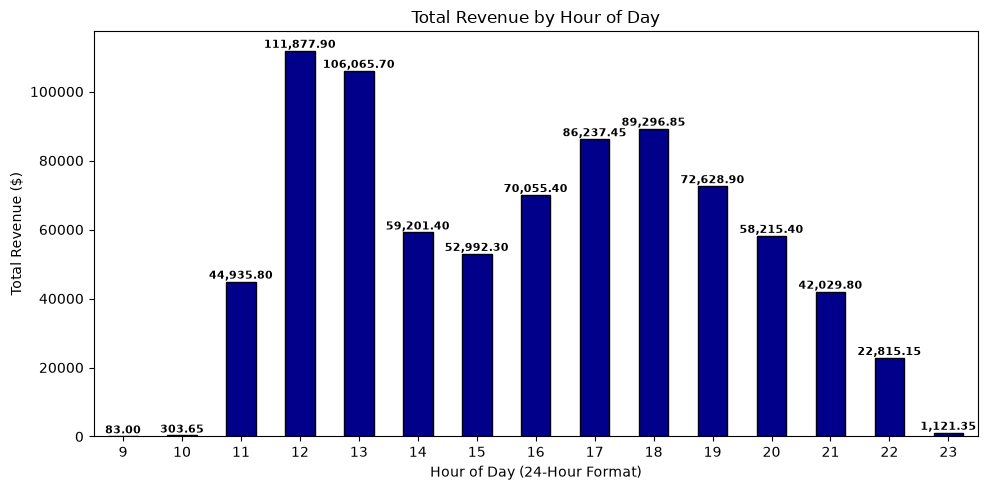

In [22]:
# 1. Convert order_time to datetime format
df['order_time'] = pd.to_datetime(df['order_time'], format='%H:%M:%S')

# 2. Extract the hour
df['order_hour'] = df['order_time'].dt.hour

# 3. Group by hour and sum total revenue
revenue_by_hour = df.groupby('order_hour', observed=False)['total_price'].sum()

# 4. Plot the bar chart
ax = revenue_by_hour.plot(
    kind='bar', figsize=(10, 5), color='darkblue', edgecolor='black'
)

plt.title('Total Revenue by Hour of Day')
plt.xlabel('Hour of Day (24-Hour Format)')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=0)

# 5. Add data labels on top of each bar
for i, val in enumerate(revenue_by_hour):
  plt.text(
      i,
      val + 50,
      f'{val:,.2f}',
      ha='center',
      va='bottom',
      fontsize=8,
      fontweight='bold',
  )

plt.tight_layout()
plt.show()

### Monthly Trend for Total Orders

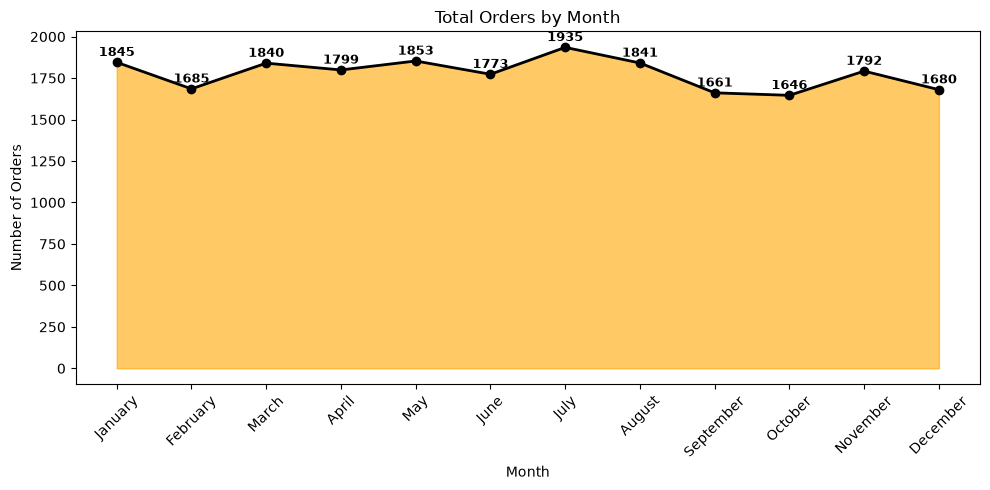

In [23]:
# 1. Convert order_date to datetime format
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

# 2. Extract full month name
df['month_name'] = df['order_date'].dt.month_name()

# 3. Define correct chronological order for months
month_order = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December',
]

# 4. Categorize month names to preserve chronological order in plots
df['month_name'] = pd.Categorical(
    df['month_name'], categories=month_order, ordered=True
)

# 5. Group by month name and count unique order IDs
orders_by_month = df.groupby('month_name', observed=False)['order_id'].nunique()

# 6. Plot the figure with filled line area
plt.figure(figsize=(10, 5))
plt.fill_between(
    orders_by_month.index, orders_by_month.values, color='orange', alpha=0.6
)
plt.plot(
    orders_by_month.index,
    orders_by_month.values,
    color='black',
    linewidth=2,
    marker='o',
)

plt.title('Total Orders by Month')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)

# 7. Add data labels on top of each point
for i, val in enumerate(orders_by_month):
  plt.text(
      i, val + 20, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold'
  )

plt.tight_layout()
plt.show()

### % of Sales by Category 

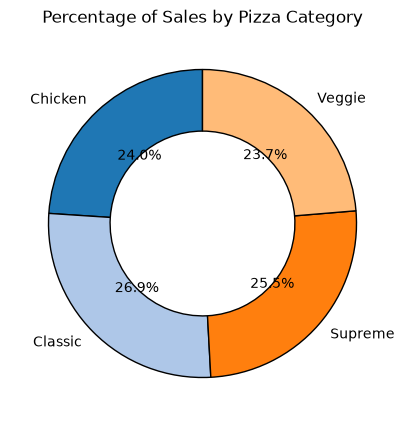

In [25]:
# 1. Group by pizza category and calculate total sales (sum of total_price)
category_sales = df.groupby('pizza_category')['total_price'].sum()

# 2. Calculate percentage of sales for each category
category_pct = category_sales / category_sales.sum() * 100

# 3. Create figure
plt.figure(figsize=(5, 5))

# 4. Define color palette
colors = plt.get_cmap('tab20').colors  # nice color palette

# 5. Plot donut/pie chart
plt.pie(
    category_pct,
    labels=category_pct.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'black', 'width': 0.4},
)

plt.title('Percentage of Sales by Pizza Category')
plt.show()

### % Sales by Pizza Size & Category 

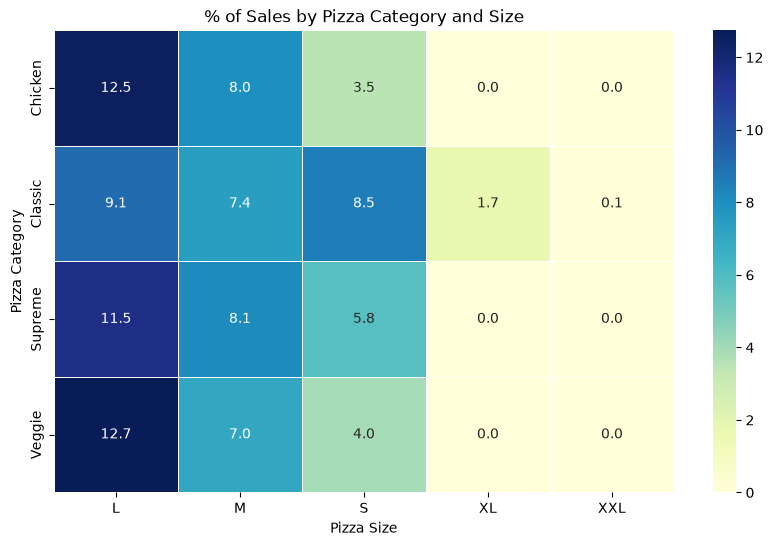

In [26]:

# 1. Create a pivot table of total sales by Category (rows) and Size (columns)
sales_pivot = df.pivot_table(
    index='pizza_category',
    columns='pizza_size',
    values='total_price',
    aggfunc='sum',
    fill_value=0,
)

# 2. Calculate percentage of total overall sales
sales_pct = sales_pivot / sales_pivot.sum().sum() * 100

# 3. Create figure and plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    sales_pct, annot=True, fmt='.1f', cmap='YlGnBu', linewidths=0.5
)

# 4. Set labels and title
plt.title('% of Sales by Pizza Category and Size')
plt.ylabel('Pizza Category')
plt.xlabel('Pizza Size')

plt.show()

### Total Pizzas Sold by Pizza Category

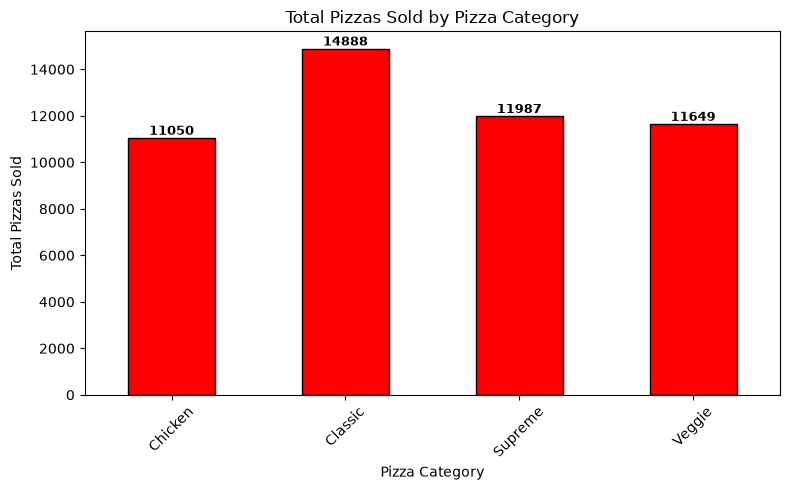

In [28]:
# 1. Group by pizza category and calculate the sum of quantity
pizzas_by_category = df.groupby('pizza_category')['quantity'].sum()

# 2. Get colors from tab20 colormap
colors = list(plt.get_cmap('tab20').colors)
colors = colors[: len(pizzas_by_category)]

# 3. Plot the bar chart
ax = pizzas_by_category.plot(
    kind='bar', figsize=(8, 5), color='red', edgecolor='black'
)

# 4. Set title and axis labels
plt.title('Total Pizzas Sold by Pizza Category')
plt.xlabel('Pizza Category')
plt.ylabel('Total Pizzas Sold')
plt.xticks(rotation=45)

# 5. Add data labels on top of each bar
for i, val in enumerate(pizzas_by_category):
  plt.text(
      i, val + 5, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold'
  )

plt.tight_layout()
plt.show()

### Top 5 Best selling Pizzas - Total Qty

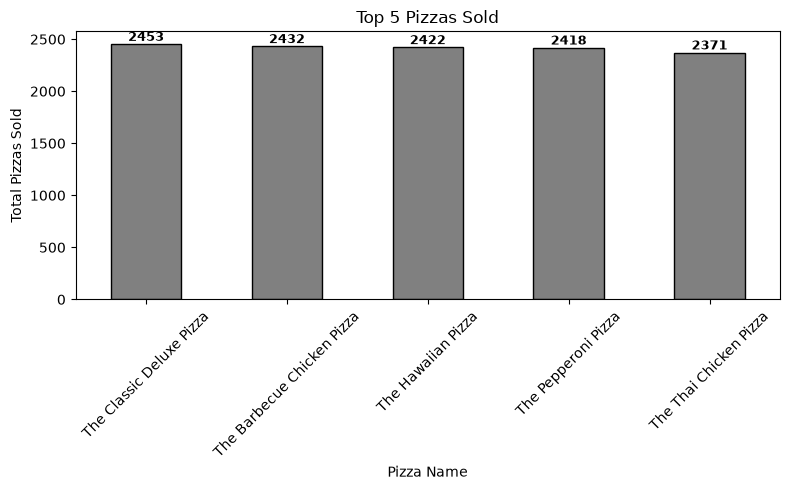

In [29]:
# 1. Group by pizza name and calculate total quantity sold
pizzas_by_name = df.groupby('pizza_name')['quantity'].sum()

# 2. Get the top 5 best-selling pizzas sorted in descending order
top5 = pizzas_by_name.sort_values(ascending=False).head(5)

# 3. Plot the bar chart
ax = top5.plot(
    kind='bar', figsize=(8, 5), color='grey', edgecolor='black'
)

# 4. Set title and axis labels
plt.title('Top 5 Pizzas Sold')
plt.xlabel('Pizza Name')
plt.ylabel('Total Pizzas Sold')
plt.xticks(rotation=45)

# 5. Add data labels on top of each bar
for i, val in enumerate(top5):
  plt.text(
      i, val + 2, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold'
  )

plt.tight_layout()
plt.show()

### Top 5 Best selling Pizzas - Total Orders

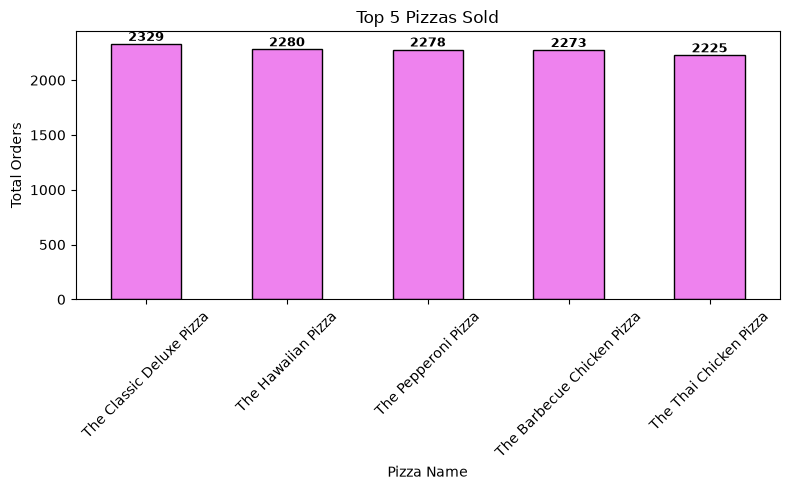

In [31]:
# 1. Group by pizza name and calculate unique order IDs
pizzas_by_name = df.groupby('pizza_name')['order_id'].nunique()

# 2. Get top 5 best-selling pizzas by total orders
top5 = pizzas_by_name.sort_values(ascending=False).head(5)

# 3. Plot the bar chart
ax = top5.plot(
    kind='bar', figsize=(8, 5), color='violet', edgecolor='black'
)

# 4. Set title and axis labels
plt.title('Top 5 Pizzas Sold')
plt.xlabel('Pizza Name')
plt.ylabel('Total Orders')
plt.xticks(rotation=45)

# 5. Add data labels on top of each bar
for i, val in enumerate(top5):
  plt.text(
      i, val + 2, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold'
  )

plt.tight_layout()
plt.show()

### Top 5 Best selling Pizzas - Total Revenue

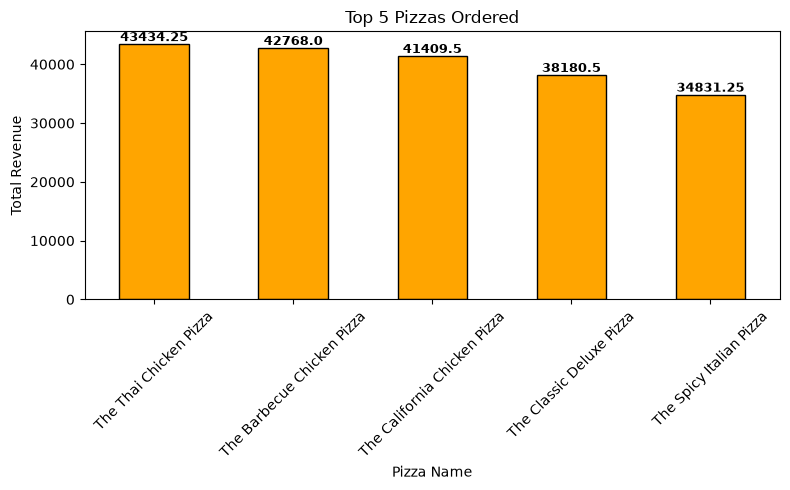

In [40]:
# 1. Group by pizza name and calculate total sales (sum of total_price)
pizzas_by_name = df.groupby('pizza_name')['total_price'].sum()

# 2. Get top 5 best-selling pizzas by total sales
top5 = pizzas_by_name.sort_values(ascending=False).head(5)

# 3. Plot the bar chart
ax = top5.plot(
    kind='bar', figsize=(8, 5), color='orange', edgecolor='black'
)

# 4. Set title and axis labels
plt.title('Top 5 Pizzas Ordered')
plt.xlabel('Pizza Name')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)

# 5. Add data labels on top of each bar
for i, val in enumerate(top5):
  plt.text(
      i, val + 2, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold'
  )

plt.tight_layout()
plt.show()

### Bottom 5 Pizzas Sold by Total Revenue

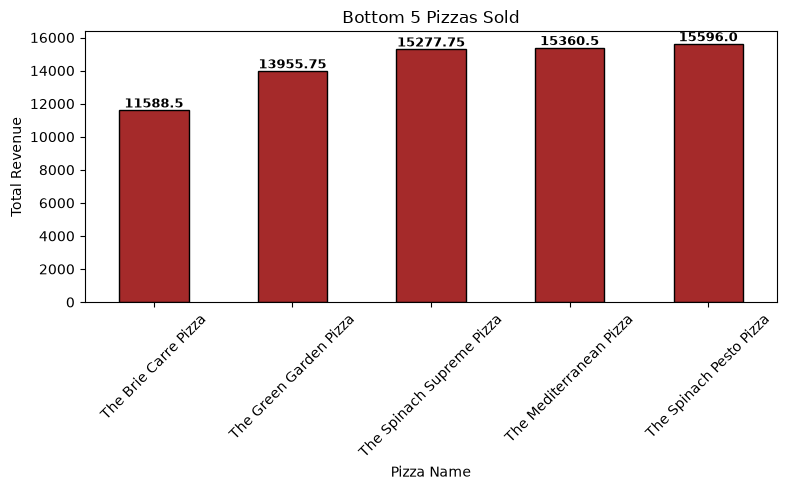

In [39]:
# 1. Group by pizza name and calculate total sales (sum of total_price)
pizzas_by_name = df.groupby('pizza_name')['total_price'].sum()

# 2. Sort values in ascending order to get the bottom 5 pizzas
bottom5 = pizzas_by_name.sort_values(ascending=True).head(5)

# 3. Plot the bar chart
ax = bottom5.plot(
    kind='bar', figsize=(8, 5), color='brown', edgecolor='black'
)

# 4. Set title and axis labels
plt.title('Bottom 5 Pizzas Sold')
plt.xlabel('Pizza Name')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)

# 5. Add data labels on top of each bar
for i, val in enumerate(bottom5):
  plt.text(
      i, val + 2, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold'
  )

plt.tight_layout()
plt.show()

### Bottom 5 Pizza Sold by Total Orders

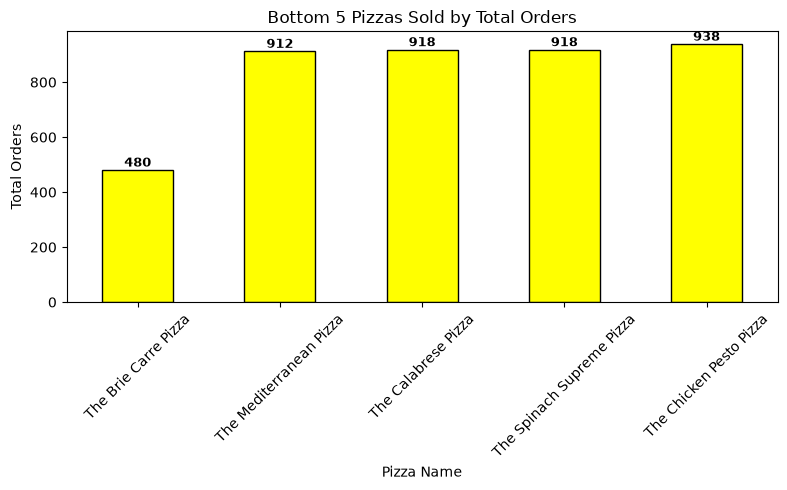

In [37]:
# 1. Group by pizza name and count unique order IDs
pizzas_by_name = df.groupby('pizza_name')['order_id'].nunique()

# 2. Sort values in ascending order to get the bottom 5 pizzas by total orders
bottom5 = pizzas_by_name.sort_values(ascending=True).head(5)

# 3. Plot the bar chart
ax = bottom5.plot(
    kind='bar', figsize=(8, 5), color='yellow', edgecolor='black'
)

# 4. Set title and axis labels
plt.title('Bottom 5 Pizzas Sold by Total Orders')
plt.xlabel('Pizza Name')
plt.ylabel('Total Orders')
plt.xticks(rotation=45)

# 5. Add data labels on top of each bar
for i, val in enumerate(bottom5):
  plt.text(
      i, val + 2, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold'
  )

plt.tight_layout()
plt.show()

### Bottom 5 Pizzas sold by Total Qty

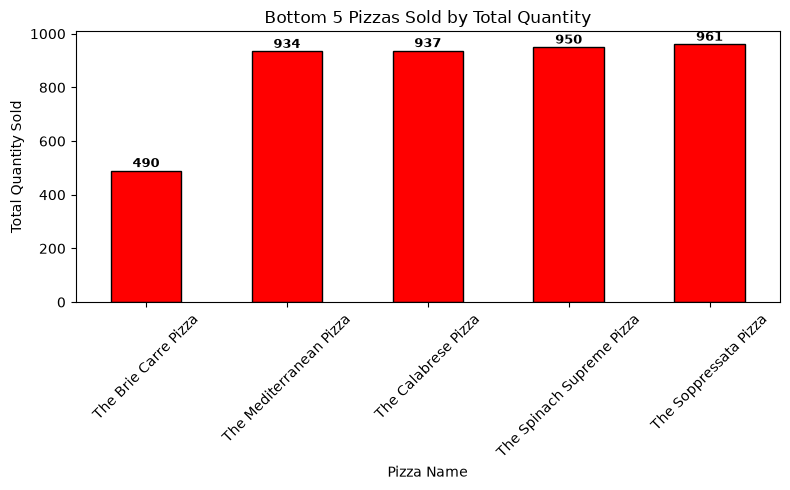

In [38]:
# 1. Group by pizza name and calculate total quantity sold
pizzas_by_name = df.groupby('pizza_name')['quantity'].sum()

# 2. Sort values in ascending order to get the bottom 5 pizzas by quantity
bottom5 = pizzas_by_name.sort_values(ascending=True).head(5)

# 3. Plot the bar chart
ax = bottom5.plot(
    kind='bar', figsize=(8, 5), color='red', edgecolor='black'
)

# 4. Set title and axis labels
plt.title('Bottom 5 Pizzas Sold by Total Quantity')
plt.xlabel('Pizza Name')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)

# 5. Add data labels on top of each bar
for i, val in enumerate(bottom5):
  plt.text(
      i, val + 2, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold'
  )

plt.tight_layout()
plt.show()